# Credit Scoring Model - 05: Multivariate Analysis

**Objective:** Analyze relationships between multiple features — correlation matrix, multicollinearity, and feature interactions.

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from eda_utils import load_data, correlation_analysis

# Enable inline plotting for Jupyter
%matplotlib inline

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = load_data('../data/cs-training-cleaned.csv')
print('✓ Using cleaned data from notebook 02 (missing values imputed with mean method)')

numerical_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

✓ Using cleaned data from notebook 02 (missing values imputed with mean method)
Dataset loaded: 150,000 rows × 11 columns


## 1. Correlation Matrix

✓ Figure saved: ../outputs/05_correlation_matrix.png


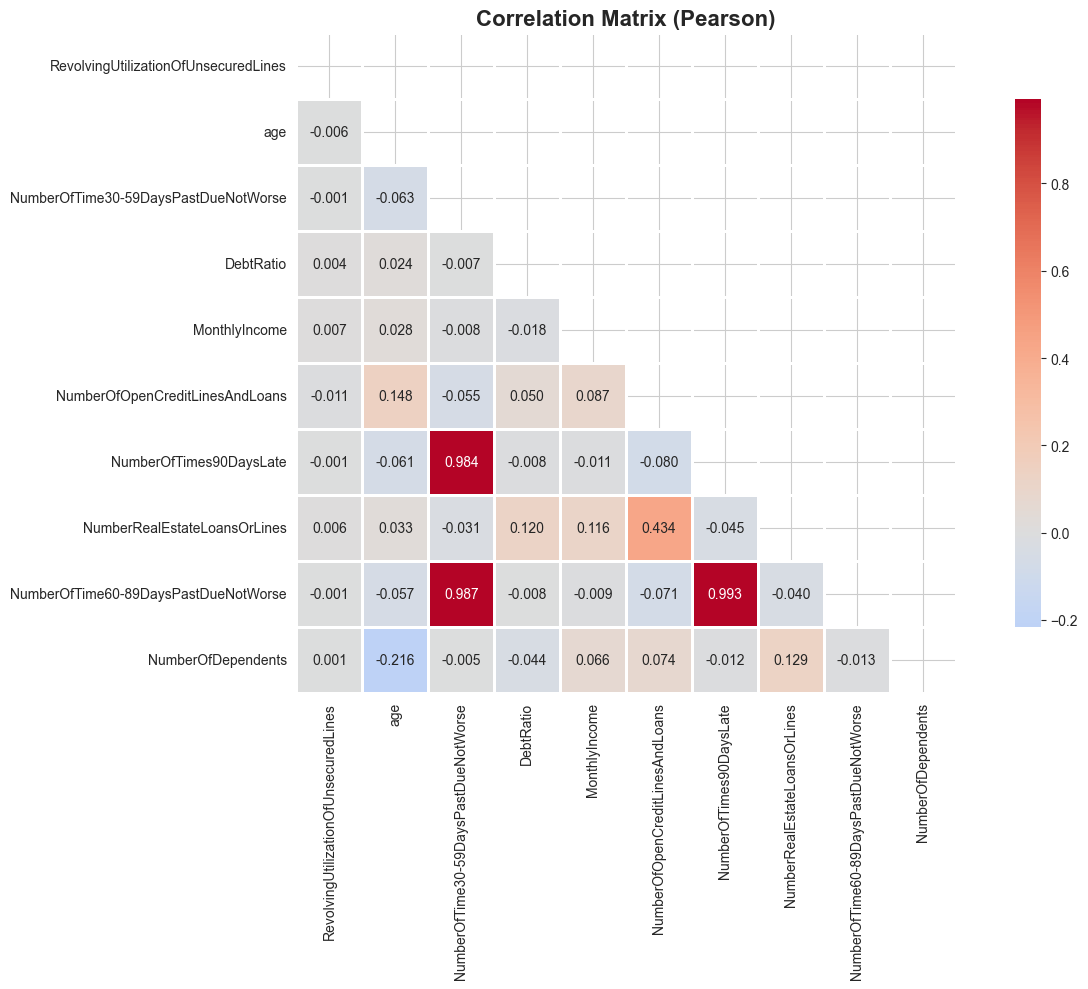


Highly Correlated Feature Pairs (|r| > 0.7):
  NumberOfTime30-59DaysPastDueNotWorse <-> NumberOfTimes90DaysLate: 0.984
  NumberOfTime30-59DaysPastDueNotWorse <-> NumberOfTime60-89DaysPastDueNotWorse: 0.987
  NumberOfTimes90DaysLate <-> NumberOfTime60-89DaysPastDueNotWorse: 0.993

⚠️  Consider removing one feature from highly correlated pairs to avoid multicollinearity.


In [2]:
fig, corr_matrix = correlation_analysis(df, numerical_features, method='pearson')
fig.savefig(f'{OUTPUT_DIR}/05_correlation_matrix.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/05_correlation_matrix.png')
plt.show()

print('\nHighly Correlated Feature Pairs (|r| > 0.7):')
print('=' * 80)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))
            print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}')

if not high_corr:
    print('  No highly correlated feature pairs found.')
else:
    print('\n⚠️  Consider removing one feature from highly correlated pairs to avoid multicollinearity.')

## 2. Feature Correlation with Target

✓ Figure saved: ../outputs/05_feature_target_correlation.png


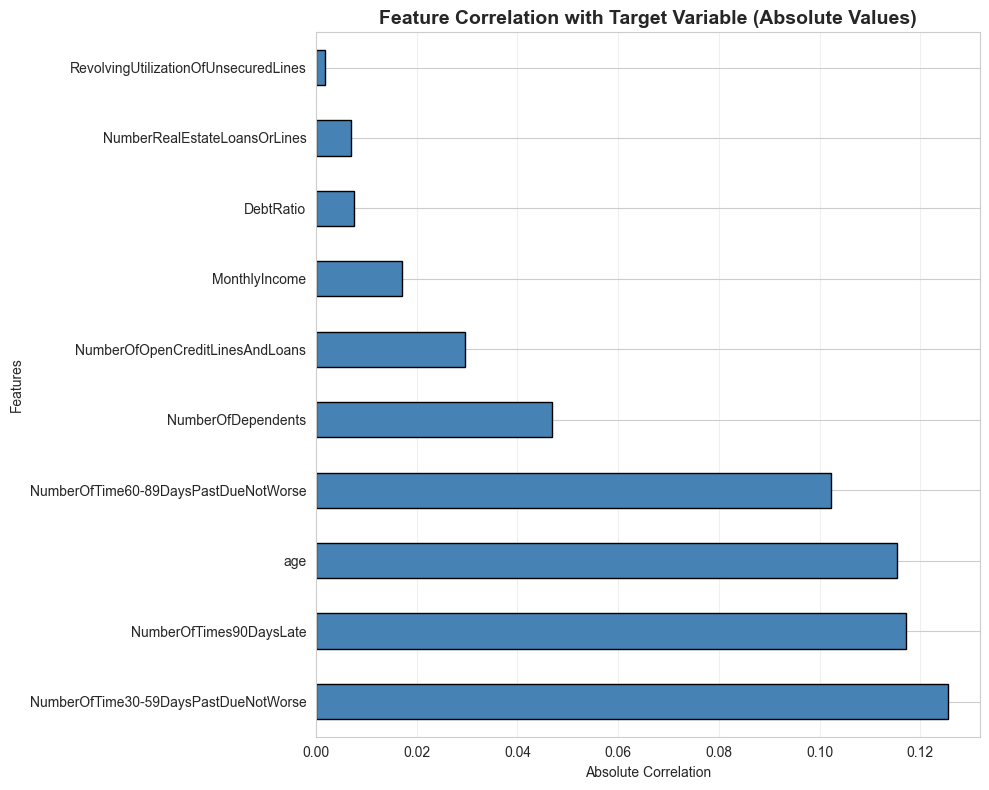


Top 5 Features Correlated with Default:
  NumberOfTime30-59DaysPastDueNotWorse: 0.1256
  NumberOfTimes90DaysLate: 0.1172
  age: -0.1154
  NumberOfTime60-89DaysPastDueNotWorse: 0.1023
  NumberOfDependents: 0.0469


In [3]:
target_corr = df[numerical_features + ['SeriousDlqin2yrs']].corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
target_corr_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Correlation with Target Variable (Absolute Values)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.set_ylabel('Features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/05_feature_target_correlation.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/05_feature_target_correlation.png')
plt.show()

print('\nTop 5 Features Correlated with Default:')
print('=' * 60)
for feature, corr_val in target_corr_sorted.head(5).items():
    print(f'  {feature}: {target_corr[feature]:.4f}')

## 3. Pairplot of Key Features

✓ Figure saved: ../outputs/05_pairplot_key_features.png


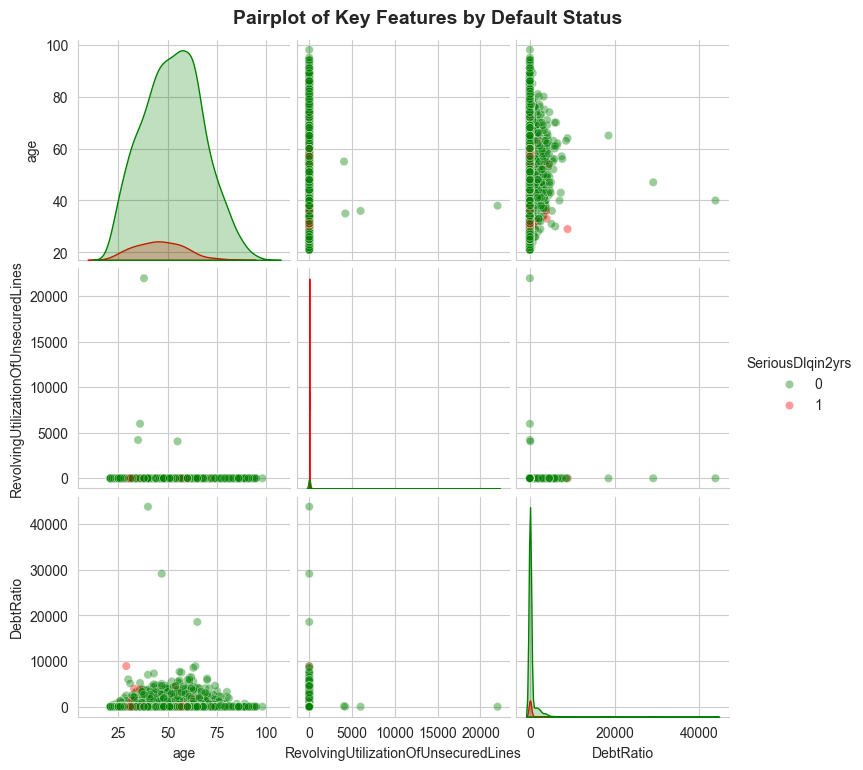


✓ Notebook 05 complete. Figures saved to outputs/


In [4]:
key_features = ['age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'SeriousDlqin2yrs']
sample_df = df[key_features].dropna().sample(n=min(3000, len(df)), random_state=42)

pair_fig = sns.pairplot(sample_df, hue='SeriousDlqin2yrs', diag_kind='kde',
                        plot_kws={'alpha': 0.4},
                        palette={0: 'green', 1: 'red'})
pair_fig.fig.suptitle('Pairplot of Key Features by Default Status', y=1.02,
                      fontsize=14, fontweight='bold')
pair_fig.savefig(f'{OUTPUT_DIR}/05_pairplot_key_features.png', dpi=120, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/05_pairplot_key_features.png')
plt.show()

print('\n✓ Notebook 05 complete. Figures saved to outputs/')